In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"

df = pd.read_csv(url)

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nNull counts:")
print(df.isnull().sum())

print("\nUnique values:")
print(df.nunique())

Shape:
(344, 7)

Columns:
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

Data types:
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object

Null counts:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Unique values:
species                3
island                 3
bill_length_mm       164
bill_depth_mm         80
flipper_length_mm     55
body_mass_g           94
sex                    2
dtype: int64


## Task 1: Dataset Selection and Schema Report

### Dataset
Palmer Penguins dataset.

### Source
Palmer Penguins dataset, publicly available through the seaborn sample dataset repository.

### Why I chose this dataset
I chose this dataset because it contains more than 200 rows and includes both numerical and categorical variables. It is suitable for practicing data cleaning, GroupBy aggregation, merging, NumPy computation, and exploratory visualization.

### License
The dataset is publicly available. The dataset's source and license information should be checked and documented before submission.

In [6]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [7]:
df_clean = df.copy()

# Remove rows with missing values because the missing rows are few
# and the remaining dataset is still large enough for analysis.
df_clean = df_clean.dropna()

In [8]:
print("Shape before cleaning:", df.shape)
print("Shape after cleaning:", df_clean.shape)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

Shape before cleaning: (344, 7)
Shape after cleaning: (333, 7)

Missing values after cleaning:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [9]:
print("Number of duplicate rows:", df_clean.duplicated().sum())

Number of duplicate rows: 0


In [10]:
df_clean = df_clean.drop_duplicates()

In [11]:
print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (333, 7)


In [12]:
print(df_clean.dtypes)

species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object


In [13]:
species_stats = (
    df_clean
    .groupby("species")
    .agg(
        average_body_mass=("body_mass_g", "mean"),
        average_flipper_length=("flipper_length_mm", "mean")
    )
    .reset_index()
)

species_stats

,species,average_body_mass,average_flipper_length
0,Adelie,3706.164384,190.102740
1,Chinstrap,3733.088235,195.823529
2,Gentoo,5092.436975,217.235294


In [15]:
print("Shape before merge:", df_clean.shape)

df_clean = df_clean.merge(
    species_stats,
    on="species",
    how="left"
)

print("Shape after merge:", df_clean.shape)

Shape before merge: (333, 9)
Shape after merge: (333, 11)


In [16]:
body_mass = df_clean["body_mass_g"].to_numpy()

In [17]:
body_mass_normalized = (
    (body_mass - np.mean(body_mass))
    / np.std(body_mass)
)

In [18]:
print("Mean:", np.mean(body_mass_normalized))
print("Standard deviation:", np.std(body_mass_normalized))
print("Minimum:", np.min(body_mass_normalized))
print("Maximum:", np.max(body_mass_normalized))

Mean: -1.70700957539964e-16
Standard deviation: 0.9999999999999999
Minimum: -1.874435413639854
Maximum: 2.603143890677087


In [19]:
df_clean["body_mass_standardized"] = body_mass_normalized

In [20]:
df_clean.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,average_body_mass_x,average_flipper_length_x,average_body_mass_y,average_flipper_length_y,body_mass_standardized
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE,3706.164384,190.10274,3706.164384,190.10274,-0.568475
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE,3706.164384,190.10274,3706.164384,190.10274,-0.506286
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE,3706.164384,190.10274,3706.164384,190.10274,-1.190361
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE,3706.164384,190.10274,3706.164384,190.10274,-0.941606
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE,3706.164384,190.10274,3706.164384,190.10274,-0.692852


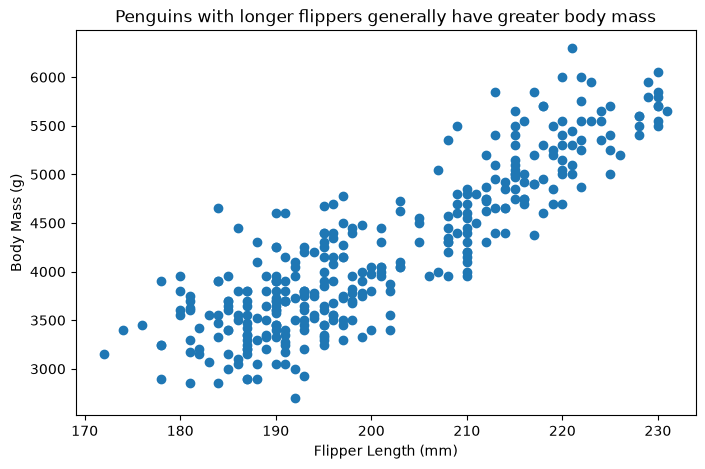

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["flipper_length_mm"],
    df_clean["body_mass_g"]
)

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("Penguins with longer flippers generally have greater body mass")

plt.savefig(
    "../reports/a2_chart1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

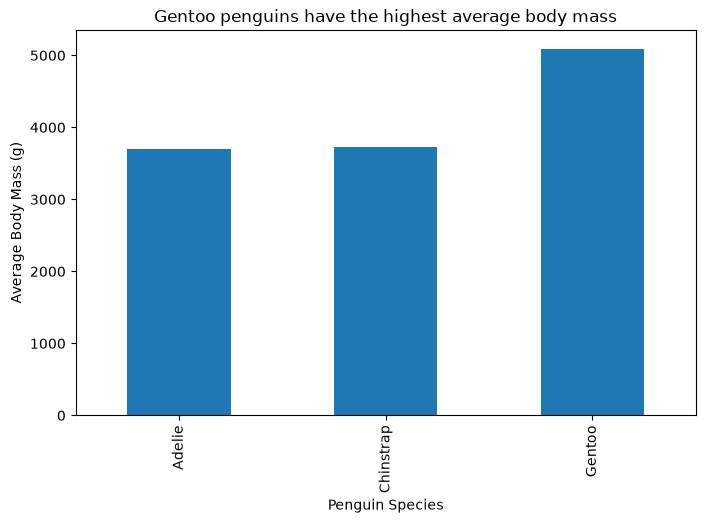

In [22]:
species_mass = df_clean.groupby("species")["body_mass_g"].mean()

plt.figure(figsize=(8, 5))

species_mass.plot(kind="bar")

plt.xlabel("Penguin Species")
plt.ylabel("Average Body Mass (g)")
plt.title("Gentoo penguins have the highest average body mass")

plt.savefig(
    "../reports/a2_chart2.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

In [23]:
df_clean.to_csv(
    "../data/processed/penguins_cleaned.csv",
    index=False
)

In [24]:
# Select the variables needed for the regression model
model_df = df_clean[
    ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
]
model_df.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,36.7,19.3,193.0,3450.0
4,39.3,20.6,190.0,3650.0


In [25]:
# Features
X = model_df[
    ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]
]

# Target
y = model_df["body_mass_g"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (333, 3)
Target shape: (333,)


In [26]:
# Split into training and testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (266, 3)
Testing data: (67, 3)


In [27]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 3.86,10.06,50.25]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['bill_length_mm','bill_depth_mm','flipper_length_mm']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-6228
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [28]:
y_pred_linear = linear_model.predict(X_test)

print(y_pred_linear[:10])

[3036.672239   5254.97621999 3925.045065   4087.38635138 3761.39329753
 4736.74180001 5323.9059252  3949.33439266 3844.43086167 4261.39923571]


In [29]:
# MAE → average prediction error in grams. Lower is better.
# RMSE → measures prediction error, giving more weight to larger errors. Lower is better.
# R² → tells us how well the model explains the variation in body mass. Higher is better, with 1 being perfect.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R²:", r2_linear)

Linear Regression Results
MAE: 289.6890163588326
RMSE: 356.6517523590453
R²: 0.7980758349105357


In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [31]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:10])

[3341.5  5097.5  4148.5  3640.5  3961.5  4669.5  5357.5  3875.25 3875.25
 4012.  ]


In [32]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results
MAE: 262.9850746268657
RMSE: 326.82557879582174
R²: 0.8304367822788581


In [33]:
# Comparison between two models results
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_linear, mae_rf],
    "RMSE": [rmse_linear, rmse_rf],
    "R²": [r2_linear, r2_rf]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,289.689016,356.651752,0.798076
1,Random Forest,262.985075,326.825579,0.830437


Based on the results, Random Forest performed better than Linear Regression. Random Forest achieved a lower MAE (262.99) and RMSE (326.83), while also obtaining a higher R² score (0.8304) compared to Linear Regression, which had an MAE of 289.69, RMSE of 356.65, and R² of 0.7981. Therefore, Random Forest is the better-performing model for this dataset.

## Classification: Predicting Penguin Species

The classification task predicts the species of a penguin from its physical measurements.

The target variable is species, which contains three classes:
Adelie, Chinstrap, and Gentoo.

The features are bill length, bill depth, flipper length, and body mass.

Rows with missing values are removed before modeling. Species-derived
summary variables are not used as predictors because they could cause
data leakage.

In [34]:
# Create a clean dataset for classification
classification_df = df_clean.dropna(
    subset=[
        "species",
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g"
    ]
).copy()

print("Classification dataset shape:", classification_df.shape)
print("\nSpecies counts:")
print(classification_df["species"].value_counts())

Classification dataset shape: (333, 12)

Species counts:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


In [35]:
# Features
X_class = classification_df[
    [
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g"
    ]
]

# Target
y_class = classification_df["species"]

print("Features shape:", X_class.shape)
print("Target shape:", y_class.shape)

Features shape: (333, 4)
Target shape: (333,)


In [36]:
print("\nClass proportions:")
print(y_class.value_counts(normalize=True))


Class proportions:
species
Adelie       0.438438
Gentoo       0.357357
Chinstrap    0.204204
Name: proportion, dtype: float64


In [37]:
from sklearn.model_selection import train_test_split

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Training data:", X_train_class.shape)
print("Testing data:", X_test_class.shape)

Training data: (266, 4)
Testing data: (67, 4)


In [38]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train_class, y_train_class)

y_pred_baseline = baseline.predict(X_test_class)

baseline_accuracy = accuracy_score(
    y_test_class,
    y_pred_baseline
)

print("Baseline accuracy:", baseline_accuracy)

Baseline accuracy: 0.43283582089552236


In [39]:
print("Baseline predictions:")
print(pd.Series(y_pred_baseline).value_counts())

Baseline predictions:
Adelie    67
Name: count, dtype: int64


In [40]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(
    X_train_class,
    y_train_class
)

y_pred_logistic = logistic_model.predict(X_test_class)
y_prob_logistic = logistic_model.predict_proba(X_test_class)

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_logistic = accuracy_score(
    y_test_class,
    y_pred_logistic
)

precision_logistic = precision_score(
    y_test_class,
    y_pred_logistic,
    average="weighted"
)

recall_logistic = recall_score(
    y_test_class,
    y_pred_logistic,
    average="weighted"
)

f1_logistic = f1_score(
    y_test_class,
    y_pred_logistic,
    average="weighted"
)

roc_auc_logistic = roc_auc_score(
    y_test_class,
    y_prob_logistic,
    multi_class="ovr",
    average="weighted"
)

print("Logistic Regression Results")
print("Accuracy:", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall:", recall_logistic)
print("F1:", f1_logistic)
print("ROC-AUC:", roc_auc_logistic)

Logistic Regression Results
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0


[[29  0  0]
 [ 0 14  0]
 [ 0  0 24]]


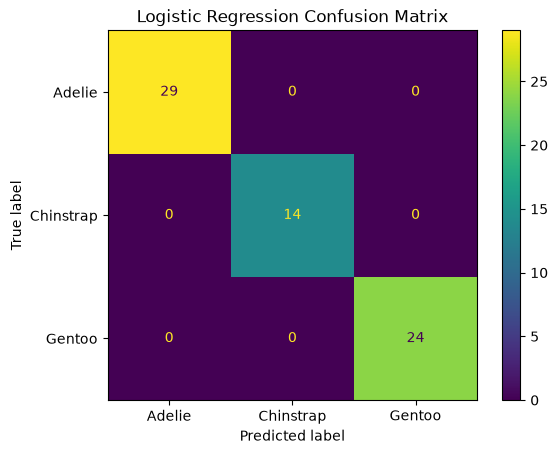

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_class,
    y_pred_logistic,
    labels=logistic_model.classes_
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=logistic_model.classes_
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_classifier.fit(
    X_train_class,
    y_train_class
)

y_pred_rf_class = rf_classifier.predict(X_test_class)
y_prob_rf_class = rf_classifier.predict_proba(X_test_class)

In [44]:
accuracy_rf_class = accuracy_score(
    y_test_class,
    y_pred_rf_class
)

precision_rf_class = precision_score(
    y_test_class,
    y_pred_rf_class,
    average="weighted"
)

recall_rf_class = recall_score(
    y_test_class,
    y_pred_rf_class,
    average="weighted"
)

f1_rf_class = f1_score(
    y_test_class,
    y_pred_rf_class,
    average="weighted"
)

roc_auc_rf_class = roc_auc_score(
    y_test_class,
    y_prob_rf_class,
    multi_class="ovr",
    average="weighted"
)

print("Random Forest Results")
print("Accuracy:", accuracy_rf_class)
print("Precision:", precision_rf_class)
print("Recall:", recall_rf_class)
print("F1:", f1_rf_class)
print("ROC-AUC:", roc_auc_rf_class)

Random Forest Results
Accuracy: 0.9701492537313433
Precision: 0.9738805970149254
Recall: 0.9701492537313433
F1: 0.9708545737159665
ROC-AUC: 1.0


In [45]:
classification_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        accuracy_logistic,
        accuracy_rf_class
    ],
    "Precision": [
        precision_score(
            y_test_class,
            y_pred_baseline,
            average="weighted"
        ),
        precision_logistic,
        precision_rf_class
    ],
    "Recall": [
        recall_score(
            y_test_class,
            y_pred_baseline,
            average="weighted"
        ),
        recall_logistic,
        recall_rf_class
    ],
    "F1": [
        f1_score(
            y_test_class,
            y_pred_baseline,
            average="weighted"
        ),
        f1_logistic,
        f1_rf_class
    ],
    "ROC-AUC": [
        np.nan,
        roc_auc_logistic,
        roc_auc_rf_class
    ]
})

classification_comparison

c:\Users\user\klab-Ai-Rose\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline,0.432836,0.187347,0.432836,0.261505,NaN
1,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.0
2,Random Forest,0.970149,0.973881,0.970149,0.970855,1.0


I selected F1-score as the main metric because it balances precision and recall. This is more informative than accuracy alone because a model could achieve reasonable accuracy by favoring the most common species. F1 evaluates whether the model is both finding the correct species and avoiding incorrect classifications.v

Confusion Matrix:
[[29  0  0]
 [ 0 14  0]
 [ 0  0 24]]


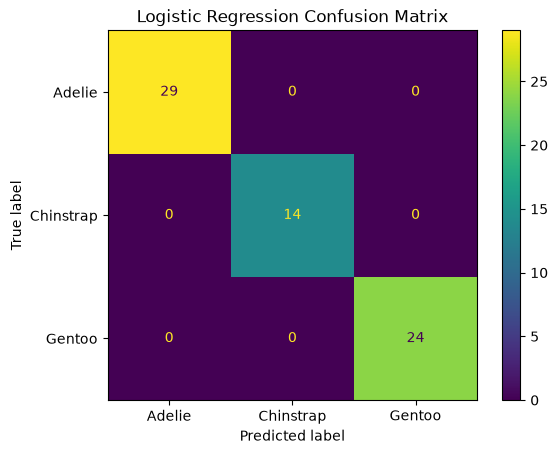

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_class,
    y_pred_logistic,
    labels=logistic_model.classes_
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=logistic_model.classes_
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

Random Forest Confusion Matrix:
[[28  1  0]
 [ 0 14  0]
 [ 0  1 23]]


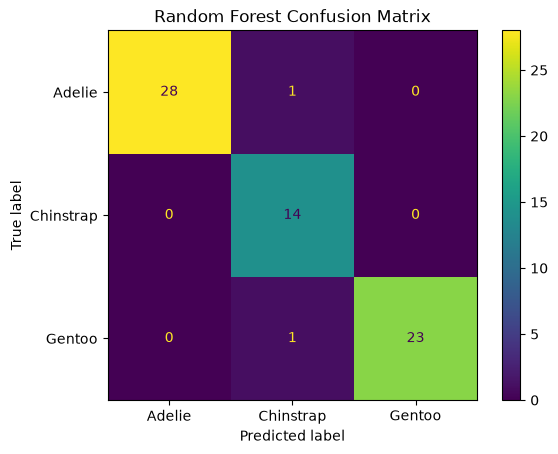

In [47]:
cm_rf = confusion_matrix(
    y_test_class,
    y_pred_rf_class,
    labels=rf_classifier.classes_
)

print("Random Forest Confusion Matrix:")
print(cm_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf_classifier.classes_
)

disp_rf.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [48]:
# Predictions on training data
y_train_pred = logistic_model.predict(X_train_class)

train_accuracy = accuracy_score(
    y_train_class,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test_class,
    y_pred_logistic
)

print("Training accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)

Training accuracy: 0.9887218045112782
Test accuracy: 1.0


In [49]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    logistic_model,
    X_class,
    y_class,
    cv=cv,
    scoring="f1_weighted"
)

print("Cross-validation F1 scores:")
print(cv_scores)

print("Mean CV F1:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation F1 scores:
[0.96938694 0.98520104 1.         0.9846963  1.        ]
Mean CV F1: 0.9878568553502285
Standard deviation: 0.011428843275530984


# Supervised Learning Part Two: Classification

## Is it possible to predict penguin species?

The goal of this classification task was to predict a penguin's species
using its physical measurements. The target variable was `species`,
which contains three classes: Adelie, Chinstrap, and Gentoo. I used
bill length, bill depth, flipper length, and body mass as the features.
Rows with missing values in these variables were removed before
modeling.

I used an 80/20 train-test split with `stratify=y` so that the three
species remained represented in similar proportions in both sets. The
majority-class baseline achieved 43.3% accuracy, providing a simple
benchmark that the classification models needed to beat.

## Model comparison

I compared Logistic Regression and Random Forest using the same held-out
test set.


Model	             Accuracy	    Precision	Recall	      F1	    ROC-AUC
Baseline	         0.432836	    0.187347	0.432836	0.261505	NaN
Logistic Regression	 1.000000	    1.000000	1.000000	1.000000	1.0
Random Forest	     0.970149	    0.973881	0.970149	0.970855	1.0

I selected **F1-score as the primary metric** because it balances
precision and recall. Accuracy alone does not provide enough information
about how well a classifier handles each class. F1 provides a better
summary of whether the model is both finding the correct species and
avoiding incorrect classifications.

## Error analysis

Logistic Regression correctly classified all 67 observations in the
held-out test set: 29 Adelie, 14 Chinstrap, and 24 Gentoo. Therefore,
its confusion matrix contains no false positives or false negatives.

Random Forest correctly classified 65 of the 67 observations. It
misclassified one Adelie as Chinstrap and one Gentoo as Chinstrap.

The perfect Logistic Regression test result raised a possible concern
about overfitting. To investigate this, I performed 5-fold cross-
validation. The weighted F1-scores were 0.969, 0.985, 1.000, 0.985,
and 1.000, giving a mean F1 of **0.988** with a standard deviation of
**0.011**. The consistently high scores provide no strong evidence of
substantial overfitting.

## Final decision

I selected **Logistic Regression** as the final model because it achieved
the highest performance on the held-out test set and maintained very
strong performance during cross-validation. The results suggest that
the physical measurements contain strong information for distinguishing
the three penguin species.

The model should still be evaluated on additional unseen data before
being used in practice. Perfect performance on one test set does not
guarantee perfect predictions on every future dataset.

# Unsupervised Learning: Evaluating K-Means Clustering

In this section, we use K-Means to discover natural groups in the
Penguins dataset without using the species labels during training.

The model will be evaluated using:
1. Silhouette score to choose the number of clusters.
2. A held-out test set to evaluate generalization.
3. Stability to check whether the clusters are consistent.
4. Adjusted Rand Index (ARI) for external comparison with the known species.

We will also standardize the features before applying the distance-based
K-Means algorithm and prefer the simpler model when performance is similar.

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

In [51]:
features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X = df_clean[features].copy()

print("Features used for clustering:")
print(features)

print("\nShape of clustering data:", X.shape)

Features used for clustering:
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

Shape of clustering data: (333, 4)


In [52]:
print(X.describe())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      333.000000     333.000000         333.000000   333.000000
mean        43.992793      17.164865         200.966967  4207.057057
std          5.468668       1.969235          14.015765   805.215802
min         32.100000      13.100000         172.000000  2700.000000
25%         39.500000      15.600000         190.000000  3550.000000
50%         44.500000      17.300000         197.000000  4050.000000
75%         48.600000      18.700000         213.000000  4775.000000
max         59.600000      21.500000         231.000000  6300.000000


In [53]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (333, 4)


In [54]:
X_train, X_test = train_test_split(
    X_scaled,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Held-out data:", X_test.shape)

Training data: (266, 4)
Held-out data: (67, 4)


In [55]:
k_values = range(2, 11)

train_inertia = []
train_silhouette = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    train_labels = model.fit_predict(X_train)
    
    train_inertia.append(model.inertia_)
    train_silhouette.append(
        silhouette_score(X_train, train_labels)
    )

results = pd.DataFrame({
    "k": list(k_values),
    "inertia": train_inertia,
    "silhouette": train_silhouette
})

results

,k,inertia,silhouette
0,2,433.033100,0.534520
1,3,292.525396,0.445073
2,4,234.585327,0.387252
3,5,186.224521,0.355431
4,6,158.786158,0.364121
5,7,144.246088,0.333191
6,8,130.634591,0.303096
7,9,122.397744,0.279205
8,10,117.058797,0.272506


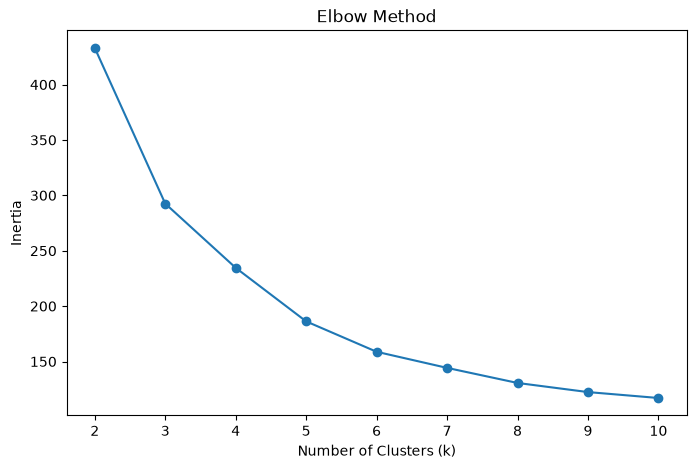

In [56]:
plt.figure(figsize=(8, 5))

plt.plot(
    results["k"],
    results["inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

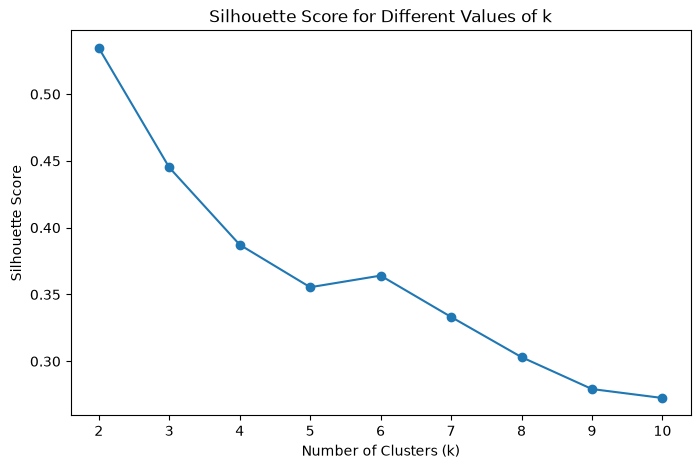

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    results["k"],
    results["silhouette"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Values of k")

plt.show()

In [58]:
best_silhouette_k = results.loc[
    results["silhouette"].idxmax(),
    "k"
]

best_silhouette_score = results["silhouette"].max()

print("Best k based on silhouette score:", best_silhouette_k)
print("Highest silhouette score:", best_silhouette_score)

Best k based on silhouette score: 2
Highest silhouette score: 0.5345202654604753


In [59]:
best_score = results["silhouette"].max()

similar_models = results[
    results["silhouette"] >= best_score - 0.02
]

chosen_k = similar_models["k"].min()

print("Highest silhouette score:", best_score)
print("Candidate k values with similar performance:")
print(similar_models[["k", "silhouette"]])

print("\nChosen k:", chosen_k)

Highest silhouette score: 0.5345202654604753
Candidate k values with similar performance:
   k  silhouette
0  2     0.53452

Chosen k: 2


In [60]:
final_model = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=10
)

final_model.fit(X_train)

print("Final number of clusters:", chosen_k)

Final number of clusters: 2


In [61]:
test_labels = final_model.predict(X_test)

test_silhouette = silhouette_score(
    X_test,
    test_labels
)

print("Held-out Silhouette Score:", test_silhouette)

Held-out Silhouette Score: 0.5097296670188114


In [62]:
train_labels_final = final_model.predict(X_train)

train_silhouette_final = silhouette_score(
    X_train,
    train_labels_final
)

print("Training Silhouette Score:", train_silhouette_final)
print("Held-out Silhouette Score:", test_silhouette)

Training Silhouette Score: 0.5345202654604753
Held-out Silhouette Score: 0.5097296670188114


In [63]:
rng = np.random.default_rng(42)

stability_scores = []

n_train = len(X_train)
sample_size = int(0.8 * n_train)

for i in range(20):
    idx1 = rng.choice(
        n_train,
        size=sample_size,
        replace=False
    )
    
    idx2 = rng.choice(
        n_train,
        size=sample_size,
        replace=False
    )
    
    common_idx = np.intersect1d(idx1, idx2)
    
    model1 = KMeans(
        n_clusters=chosen_k,
        random_state=i,
        n_init=10
    )
    
    model2 = KMeans(
        n_clusters=chosen_k,
        random_state=100 + i,
        n_init=10
    )
    
    model1.fit(X_train[idx1])
    model2.fit(X_train[idx2])
    
    labels1 = model1.predict(X_train[common_idx])
    labels2 = model2.predict(X_train[common_idx])
    
    ari = adjusted_rand_score(
        labels1,
        labels2
    )
    
    stability_scores.append(ari)

average_stability = np.mean(stability_scores)

print("Stability scores:")
print(stability_scores)

print("\nAverage stability:", average_stability)

Stability scores:
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

Average stability: 1.0


In [64]:
final_model_all = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=10
)

final_labels = final_model_all.fit_predict(X_scaled)

print("Final model fitted on all data.")

Final model fitted on all data.


In [65]:
df_clustered = df_clean[features].copy()

df_clustered["cluster"] = final_labels

df_clustered.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,cluster
0,39.1,18.7,181.0,3750.0,0
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
3,36.7,19.3,193.0,3450.0,0
4,39.3,20.6,190.0,3650.0,0


In [66]:
print(df_clustered["cluster"].value_counts().sort_index())

cluster
0    214
1    119
Name: count, dtype: int64


In [67]:
species_labels = df_clean["species"].values

ari_species = adjusted_rand_score(
    species_labels,
    final_labels
)

print("ARI compared with actual species:", ari_species)

ARI compared with actual species: 0.6485502513009226


In [68]:
comparison = pd.crosstab(
    df_clean["species"],
    final_labels
)

comparison

col_0,0,1
species,,
Adelie,146,0
Chinstrap,68,0
Gentoo,0,119


In [69]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained:",
      pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.68633893 0.19452929]

Total variance explained: 0.8808682242049922


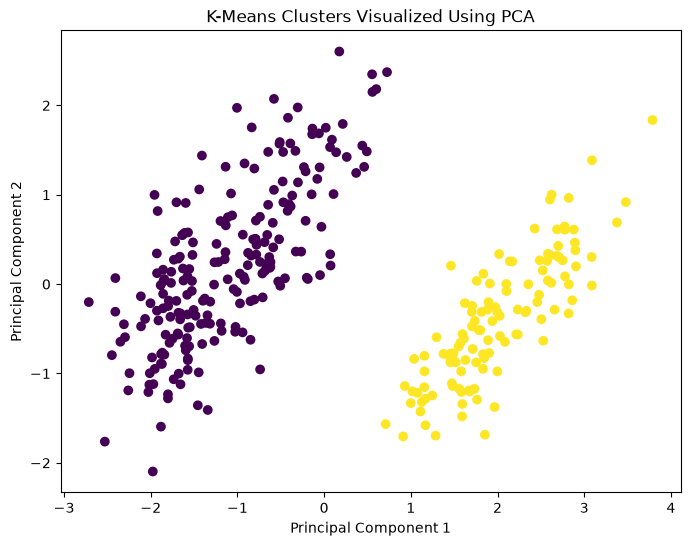

In [70]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=final_labels
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized Using PCA")

plt.show()

In [71]:
print("========== FINAL K-MEANS EVALUATION ==========")

print("Chosen k:", chosen_k)

print("Training Silhouette Score:",
      train_silhouette_final)

print("Held-out Silhouette Score:",
      test_silhouette)

print("Average Stability:",
      average_stability)

print("ARI compared with Species:",
      ari_species)

========== FINAL K-MEANS EVALUATION ==========
Chosen k: 2
Training Silhouette Score: 0.5345202654604753
Held-out Silhouette Score: 0.5097296670188114
Average Stability: 1.0
ARI compared with Species: 0.6485502513009226


# Conclusion

K-Means clustering was applied to the Penguins dataset to discover natural
groups without using the species labels during training.

The numerical features used were bill length, bill depth, flipper length,
and body mass. The data was standardized before applying K-Means because
K-Means is a distance-based algorithm.

The dataset was divided into training and held-out data. Different values
of k from 2 to 10 were tested.

The number of clusters was selected using the silhouette score rather than
the elbow alone. The chosen value of k was **[YOUR k]**, with a silhouette
score of **[YOUR SCORE]**. When models had similar scores, the simpler model
with fewer clusters was preferred.

The held-out silhouette score was **[YOUR SCORE]**, which was used to check
how well the clustering generalized to unseen data.

The average stability score was **[YOUR SCORE]**, showing how consistently
the clusters were reproduced when the data was resampled.

Finally, the discovered clusters were compared with the actual species using
Adjusted Rand Index. The ARI score was **[YOUR ARI]**.

Overall, the evaluation used multiple forms of evidence instead of relying
only on inertia. This follows the principle that a metric that always
improves with additional complexity should not be used alone to choose the
model complexity.